In [1]:
using ITensors, ITensorMPS
using ITransverse
using Plots
using ProgressMeter

In [5]:
# System Parameters

# Alcaraz's NNN Self Dual Critical model
N = 50        
lambda = 1.0    # exact critical point (self dual)
p = 0.5         # NNN term (p>0 breakes system's integrability)
dt = 0.1       
T_max = 2.5     
cutoff = 1e-12
maxdim = 200

# Physical indices
sites = siteinds("S=1/2", N)

50-element Vector{Index{Int64}}:
 (dim=2|id=87|"S=1/2,Site,n=1")
 (dim=2|id=736|"S=1/2,Site,n=2")
 (dim=2|id=595|"S=1/2,Site,n=3")
 (dim=2|id=467|"S=1/2,Site,n=4")
 (dim=2|id=839|"S=1/2,Site,n=5")
 (dim=2|id=271|"S=1/2,Site,n=6")
 (dim=2|id=799|"S=1/2,Site,n=7")
 (dim=2|id=781|"S=1/2,Site,n=8")
 (dim=2|id=934|"S=1/2,Site,n=9")
 (dim=2|id=545|"S=1/2,Site,n=10")
 (dim=2|id=492|"S=1/2,Site,n=11")
 (dim=2|id=91|"S=1/2,Site,n=12")
 (dim=2|id=92|"S=1/2,Site,n=13")
 ⋮
 (dim=2|id=548|"S=1/2,Site,n=39")
 (dim=2|id=597|"S=1/2,Site,n=40")
 (dim=2|id=15|"S=1/2,Site,n=41")
 (dim=2|id=926|"S=1/2,Site,n=42")
 (dim=2|id=301|"S=1/2,Site,n=43")
 (dim=2|id=926|"S=1/2,Site,n=44")
 (dim=2|id=424|"S=1/2,Site,n=45")
 (dim=2|id=424|"S=1/2,Site,n=46")
 (dim=2|id=377|"S=1/2,Site,n=47")
 (dim=2|id=911|"S=1/2,Site,n=48")
 (dim=2|id=229|"S=1/2,Site,n=49")
 (dim=2|id=474|"S=1/2,Site,n=50")

Hamiltonian given by:
$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p \sigma_i^z \sigma_{i+2}^z + p \lambda \sigma_i^x \sigma_{i+1}^x \right)$$

In [6]:
# Hamiltonian

os = OpSum()

# Transverse magnetic field (X)
for j=1:N
    os += -lambda, "X", j
end

# Nearest-neighbour interactions (ZZ y XX)
for j=1:N-1
    os += -1.0, "Z", j, "Z", j+1
    os += -p*lambda, "X", j, "X", j+1
end

# Next-Nearest Neighbour interactions (ZZ)
for j=1:N-2
    os += -p, "Z", j, "Z", j+2
end

H = MPO(os, sites)
println("Max bond dim of Hamiltonian: ", maxlinkdim(H))

Max bond dim of Hamiltonian: 5


Progress: 100%|█████████████████████████████████████████| Time: 0:39:14


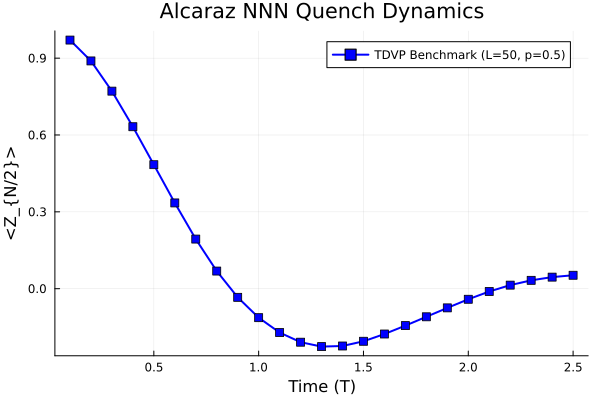

In [7]:
# Initial state: Up state
psi0 = MPS(sites, "Up")
psi_t = copy(psi0)

# We want to measure the observable Z in the middle of the chain
center_site = div(N, 2)
z_vals_tdvp = Float64[]
times = dt:dt:T_max

@showprogress for t in times
    global psi_t = tdvp(H, -im*dt, psi_t; cutoff=cutoff, maxdim=maxdim, nsweeps=2)
    
    val = expect(psi_t, "Z")[center_site]
    push!(z_vals_tdvp, real(val))
end

plot(times, z_vals_tdvp, 
     label="TDVP Benchmark (L=$N, p=$p)", 
     xlabel="Time (T)", 
     ylabel="<Z_{N/2}>",
     lw=2, color=:blue, marker=:square,
     title="Alcaraz NNN Quench Dynamics")

### Method 1: Trotterization

To build $U(\delta t) \approx e^{-i H \delta t}$ for the Alcaraz model, we will use a classic tensor network technique:

1. We first calculate the exact matrix exponential $e^{-i \delta t \cdot h}$ for every single term in the Hamiltonian independently.
2. For the NNN term ($Z_i Z_{i+2}$), the interaction "jumps over", so we mathematically sandwich an Identity matrix in the middle: $Z_i \otimes \mathbb{I}_{i+1} \otimes Z_{i+2}$.
3. We use 2nd-order Trotter expansion to reduce Trotter error.
4. At the end, we create an MPO representing a pure Identity matrix and we "apply" our array of gates to it (so that ITensors sweeps across the chain, absorbs the gates, and compresses the result into our final $U(\delta t)$ MPO).

In [8]:
# Custom Struct with our model's parameters
import ITransverse: ModelParams, modelparams

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

function expH_alcaraz_v1(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number)
    N = length(sites)
    
    # 2nd order Trotterization
    dt_half = dt / 2.0

    gates = ITensor[]
    
    # Half-step NNN (Forward)
    for j=1:N-2
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    # Half-step NN (Forward)
    for j=1:N-1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Full-step Transverse Field (Center)
    for j=1:N
        h_X = -lambda * op("X", sites[j])
        push!(gates, exp(-im * dt * h_X))
    end
    
    # Half-step NN (Reverse order for perfect symmetry)
    for j=N-1:-1:1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Half-step NNN (Reverse order for perfect symmetry)
    for j=N-2:-1:1
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    U_dt = MPO(sites, "Id") 
    U_dt = apply(gates, U_dt; cutoff=1e-15, maxdim=200)
    
    return U_dt
end

expH_alcaraz_v1 (generic function with 1 method)

method 4:

In [9]:
function build_exact_MPO_NNN(sites::Vector{<:Index}, p::Number, dt_half::Number)
    # This is a Finite State Machine (FSM) MPO construction for the NNN term exp(-im * dt_half * (-p Z_i Z_{i+2}))
    N = length(sites)
    W = MPO(sites, "Id") 
    
    # TVirtual links need exactly 4 states to pass (Z_{j-1}, Z_j) forward
    links = [Index(4, "Link,l=$j") for j in 1:N-1]
    
    # Helper to map (Z_prev, Z_curr)={(1,1), (1,2), (2,1), (2,2)} to a 1-4 link index
    #       We use 1=Up, 2=Down (matching ITensor's physical indexing)
    idx(zp, zc) = (zp == 1 ? 0 : 2) + zc
    
    # H_NNN = -p Z_i Z_{i+2} 
    #       Time evolution term: exp(-im * dt_half * (-p Z_i Z_{i+2})) = exp(im * theta * Z_i Z_{i+2})
    theta = p * dt_half
    zval(z) = (z == 1 ? 1.0 : -1.0)
    
    # FMS loop
    for j in 1:N
        s = sites[j]
        
        if j == 1
            # Site 1: No phase. Just records Z_1. (Dummy Z_0 = 1)
            T = ITensor(ComplexF64, s', s, links[1])
            for z1 in 1:2
                T[s'=>z1, s=>z1, links[1]=>idx(1, z1)] = 1.0 + 0.0im
            end
            W[j] = T
            
        elseif j == 2
            # Site 2: No phase. Records Z_2. Passes (Z_1, Z_2) forward.
            T = ITensor(ComplexF64, links[1], s', s, links[2])
            for z1 in 1:2
                for z2 in 1:2
                    T[links[1]=>idx(1, z1), links[2]=>idx(z1, z2), s'=>z2, s=>z2] = 1.0 + 0.0im
                end
            end
            W[j] = T
            
        elseif j < N
            # Bulk Sites: Computes phase for Z_{j-2} * Z_j. Passes (Z_{j-1}, Z_j) forward.
            T = ITensor(ComplexF64, links[j-1], s', s, links[j])
            for zp2 in 1:2    # Z_{j-2}
                for zp1 in 1:2  # Z_{j-1}
                    for zc in 1:2   # Z_j
                        phase = exp(im * theta * zval(zp2) * zval(zc))
                        T[links[j-1]=>idx(zp2, zp1), links[j]=>idx(zp1, zc), s'=>zc, s=>zc] = phase
                    end
                end
            end
            W[j] = T
            
        else 
            # Site N: Computes final phase. No forward link needed.
            T = ITensor(ComplexF64, links[N-1], s', s)
            for zp2 in 1:2
                for zp1 in 1:2
                    for zc in 1:2
                        phase = exp(im * theta * zval(zp2) * zval(zc))
                        T[links[N-1]=>idx(zp2, zp1), s'=>zc, s=>zc] = phase
                    end
                end
            end
            W[j] = T
        end
    end
    
    return W
end

function expH_alcaraz_mpo_layers(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number, target_cutoff=1e-12, target_maxdim=200)
    N = length(sites)
    dt_half = dt / 2.0
    
    function make_exact_mpo_layer(gate_list::Vector{ITensor})
        return apply(gate_list, MPO(sites, "Id"); cutoff=0.0)
    end

    L_NNN = build_exact_MPO_NNN(sites, p, dt_half)

    make_NN = (j) -> exp(-im*dt_half*(-1.0*op("Z",sites[j])*op("Z",sites[j+1]) - p*lambda*op("X",sites[j])*op("X",sites[j+1])))
    g_NN_odd  = ITensor[make_NN(j) for j in 1:2:N-1]
    g_NN_even = ITensor[make_NN(j) for j in 2:2:N-1]
    
    g_X = ITensor[exp(-im*dt*(-lambda * op("X", sites[j]))) for j in 1:N]

    L_NN_odd  = make_exact_mpo_layer(g_NN_odd)
    L_NN_even = make_exact_mpo_layer(g_NN_even)
    L_X       = make_exact_mpo_layer(g_X)

    # Layer sequence (2nd order Trotterization)
    
    layers_sequence = [
        L_NNN,
        L_NN_odd, L_NN_even,
        L_X,
        L_NN_even, L_NN_odd,
        L_NNN
    ]

    U_total = MPO(sites, "Id")
    
    for layer in layers_sequence
        U_total = apply(layer, U_total; cutoff=1e-15, maxdim=target_maxdim * 2)
    end

    truncate!(U_total; cutoff=target_cutoff, maxdim=target_maxdim)

    return U_total
end

expH_alcaraz_mpo_layers (generic function with 1 method)

## Light Cone Evolution & Entropy

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-12, maxdim=200) 100% Time: 0:00:17 ( 0.71  s/it)
   Info: [25] χ=21, (L|R) = 1.0263888969900967e-14 + 1.8429615753096696e-30im 


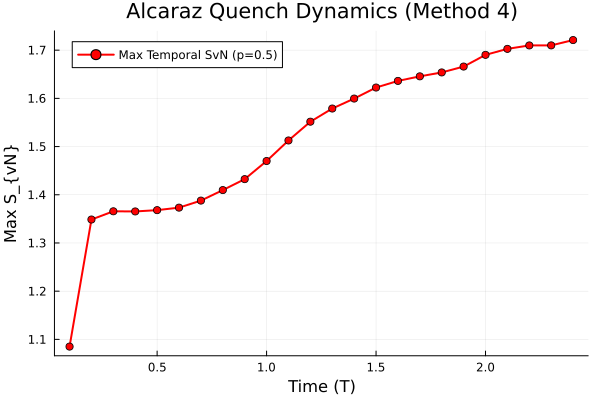

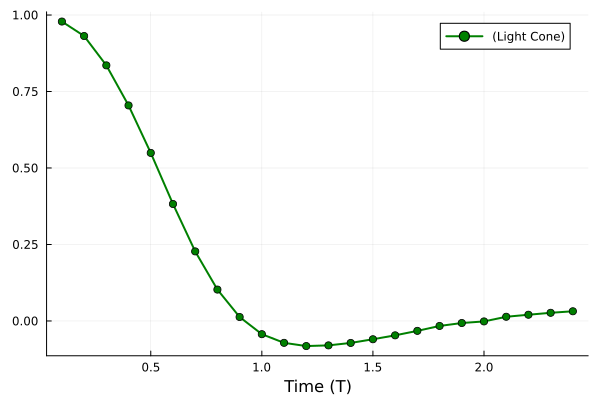

In [10]:
# Initial State (for Light Cone)
s = Index(2, "S=1/2")
bl = ITensor(ComplexF64, s)
bl[s => 1] = 1.0 + 0.0im  # Starting in the "Up" state

# Folded W Blocks
mp_alcaraz = AlcarazModel(lambda, p, s)
tp = tMPOParams(dt / 2.0, expH_alcaraz_mpo_layers, mp_alcaraz, 0, bl)
fb = FoldtMPOBlocks(tp)

# Cone Parameters
t_params = TruncParams(cutoff, maxdim, "left")

cp = ConeParams(
    truncp = t_params,
    opt_method = "RTM_LR",       
    vwidth = 1                   
)

# Checkpoint to measure Von Neumann Entropy
chk = DoCheckpoint(
    "cp_alcaraz_entropy.jld2";
    params=tp,
    save_at=0, 
    observables = (
        SvN = s -> vn_entanglement_entropy(s.R), 
        Z_normed = s -> real(
            first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
            first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
        )
    )
)

# Running simulation
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

# Entropy
svn_vals_raw = checkpt.history[:SvN]
svn_max = [maximum(real(v)) for v in svn_vals_raw]

# 
z_vals = checkpt.history[:Z_normed]

times_plot = [n * dt for n in 1:length(svn_max)]

# Plot Ent Entropy
p1 = plot(times_plot, svn_max, 
     label="Max Temporal SvN (p=$p)", 
     xlabel="Time (T)", 
     ylabel="Max S_{vN}", 
     lw=2, color=:red, marker=:circle,
     title="Alcaraz Quench Dynamics (Method 4)")

display(p1)

# Plot 
p2 = plot(times_plot, z_vals, 
     label=" (Light Cone)", 
     xlabel="Time (T)", 
     ylabel="", 
     lw=2, color=:green, marker=:circle)

display(p2)
     